# VQCFD Gradient and Legacy Variance Analysis

The reusable loading and plotting functions live in `analysis.py`. The first section remains available for old variance-mode results; the new raw-gradient workflow is below.


In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np

import analysis as an

an.configure_plots()
RESULTS_ROOT = an.RESULTS_ROOT
RESULTS_ROOT


PosixPath('/Users/joel/Documents/MA/Code/VQCFD_quimb/results')

## Discover legacy variance runs


In [2]:
variance_runs = an.discover_variance_runs()
an.print_variance_runs(variance_runs)


var_N2L1                 N=2   L=1   circuit=default    variance=0.31716497156749646 tries=4000
var_N2L2                 N=2   L=2   circuit=default    variance=0.2965365373132682 tries=4000
var_N2L4                 N=2   L=4   circuit=default    variance=0.279785533622202 tries=4000
var_N2L8                 N=2   L=8   circuit=default    variance=0.27073325456218755 tries=2000
var_N3L1                 N=3   L=1   circuit=default    variance=0.1442779785519855 tries=1000
var_N3L2                 N=3   L=2   circuit=default    variance=0.13890475032056604 tries=1000
var_N3L4                 N=3   L=4   circuit=default    variance=0.13305193118477224 tries=1000
var_N3L8                 N=3   L=8   circuit=default    variance=0.1279561159880521 tries=1000
var_N4L1                 N=4   L=1   circuit=default    variance=0.06925700385211589 tries=1000
var_N4L2                 N=4   L=2   circuit=default    variance=0.0664977257100345 tries=1000
var_N4L4                 N=4   L=4   circuit=d

## Select runs


In [4]:
# Add (dir_label, label) pairs for a controlled comparison, or leave empty to use all.
RUNS = [
    # ("var", "N2L1"),
    # ("var", "N3L1"),
]

# Each entry replaces its source runs with one variance computed from all raw gradient samples.
VARIANCE_COMBINATIONS = {
    "combined_N10L1": [("var", f"N10L1_{i}") for i in range(1, 5)],
    "combined_N10L2": [("var", f"N10L2_{i}") for i in range(1, 5)],
}

selected = [an.load_variance_run(d, label) for d, label in RUNS] if RUNS else variance_runs
selected = an.apply_variance_combinations(selected, VARIANCE_COMBINATIONS)
an.print_variance_runs(selected)
an.variance_table(selected)


var_N2L1                 N=2   L=1   circuit=default    variance=0.31716497156749646 tries=4000
var_N2L2                 N=2   L=2   circuit=default    variance=0.2965365373132682 tries=4000
var_N2L4                 N=2   L=4   circuit=default    variance=0.279785533622202 tries=4000
var_N2L8                 N=2   L=8   circuit=default    variance=0.27073325456218755 tries=2000
var_N3L1                 N=3   L=1   circuit=default    variance=0.1442779785519855 tries=1000
var_N3L2                 N=3   L=2   circuit=default    variance=0.13890475032056604 tries=1000
var_N3L4                 N=3   L=4   circuit=default    variance=0.13305193118477224 tries=1000
var_N3L8                 N=3   L=8   circuit=default    variance=0.1279561159880521 tries=1000
var_N4L1                 N=4   L=1   circuit=default    variance=0.06925700385211589 tries=1000
var_N4L2                 N=4   L=2   circuit=default    variance=0.0664977257100345 tries=1000
var_N4L4                 N=4   L=4   circuit=d

,full_label,n,l,circuit,variance,variance_tries,variance_num_samples,variance_runtime_s,gradient_mean,combined_from
0,var_N2L1,2,1,default,0.317165,4000,16000,5.563150e+03,NaN,NaN
1,var_N2L2,2,2,default,0.296537,4000,24000,5.948666e+03,NaN,NaN
2,var_N2L4,2,4,default,0.279786,4000,40000,1.535361e+04,NaN,NaN
3,var_N2L8,2,8,default,0.270733,2000,36000,2.388916e+04,NaN,NaN
4,var_N3L1,3,1,default,0.144278,1000,6000,6.930896e+02,NaN,NaN
5,var_N3L2,3,2,default,0.138905,1000,9000,1.399477e+03,NaN,NaN
6,var_N3L4,3,4,default,0.133052,1000,15000,9.662871e+03,NaN,NaN
7,var_N3L8,3,8,default,0.127956,1000,27000,3.035134e+04,NaN,NaN
8,var_N4L1,4,1,default,0.069257,1000,8000,3.053449e+03,NaN,NaN
9,var_N4L2,4,2,default,0.066498,1000,12000,2.358635e+03,NaN,NaN


## Variance plots


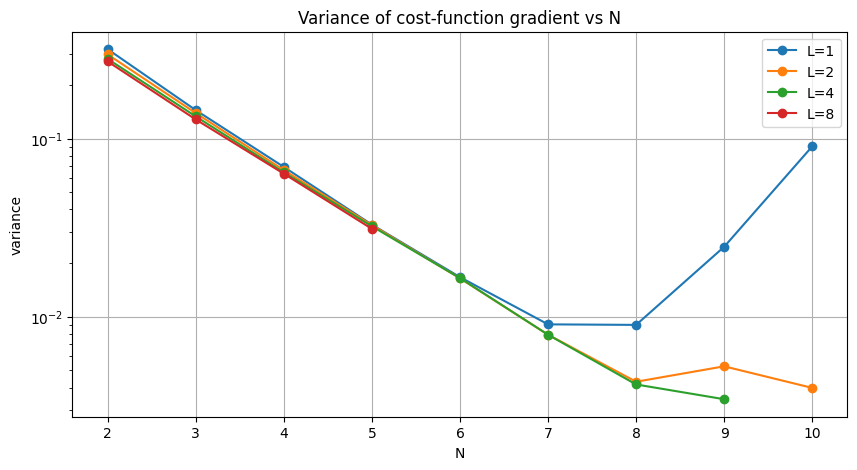

In [5]:
an.plot_variance_vs_n(selected, log_y=True);


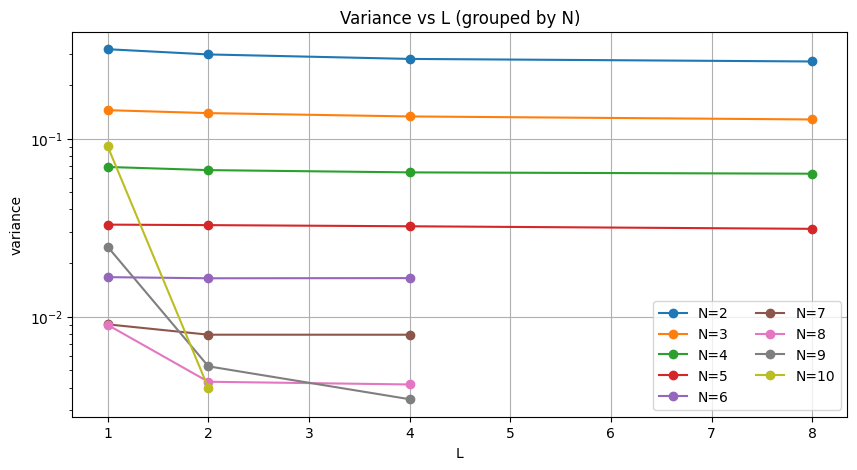

In [12]:
an.plot_variance_vs_l(selected, log_y=True);


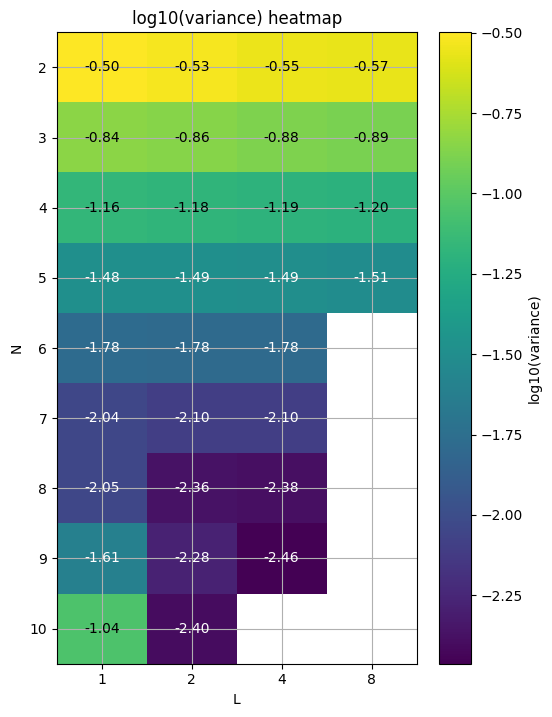

In [6]:
an.plot_variance_heatmap(selected);


## Inspect one run


In [5]:
if selected:
    selected[0]["values"]


## Discover and select gradient runs

Each run contains one raw derivative tensor with axes `(five circuits, parameters, random sweeps)`. Total-cost and contribution gradients are reconstructed from it during analysis.


In [3]:
gradient_runs = an.discover_gradient_runs()
an.print_gradient_runs(gradient_runs)


tests_N2L1                       N=2   L=1   circuit=default              gradients=5000/5000
tests_N2L2                       N=2   L=2   circuit=default              gradients=4998/5000
tests_N3L1                       N=3   L=1   circuit=default              gradients=4998/5000
tests_N3L2                       N=3   L=2   circuit=default              gradients=4995/5000
tests_N4L1                       N=4   L=1   circuit=default              gradients=5000/5000
tests_N4L2                       N=4   L=2   circuit=default              gradients=4992/5000
tests_N5L1                       N=5   L=1   circuit=default              gradients=5000/5000
tests_N5L2                       N=5   L=2   circuit=default              gradients=4995/5000
count= 8


In [4]:
# Add (dir_label, label) pairs for a controlled comparison, or leave empty to use all.
GRADIENT_RUNS = [
    # ("grad", "N2L1"),
    # ("grad", "N3L1"),
]

selected_gradient_runs = (
    [an.load_gradient_run(d, label) for d, label in GRADIENT_RUNS]
    if GRADIENT_RUNS else gradient_runs
)
an.print_gradient_runs(selected_gradient_runs)


tests_N2L1                       N=2   L=1   circuit=default              gradients=5000/5000
tests_N2L2                       N=2   L=2   circuit=default              gradients=4998/5000
tests_N3L1                       N=3   L=1   circuit=default              gradients=4998/5000
tests_N3L2                       N=3   L=2   circuit=default              gradients=4995/5000
tests_N4L1                       N=4   L=1   circuit=default              gradients=5000/5000
tests_N4L2                       N=4   L=2   circuit=default              gradients=4992/5000
tests_N5L1                       N=5   L=1   circuit=default              gradients=5000/5000
tests_N5L2                       N=5   L=2   circuit=default              gradients=4995/5000
count= 8


## Statistics over all parameters

The unprefixed `mean_gradient`, `mean_gradient_norm`, and `variance` columns describe the reconstructed total-cost gradient. The next 24 columns contain the same three statistics for contributions 1–3 and circuits 1–5. The three prefactor-free contributions are `dc1`, `dc2 - 2*dc1 + dc3`, and `dc4 - dc5`.


In [5]:
gradient_run_stats = an.gradient_run_table(selected_gradient_runs)
gradient_run_stats


,full_label,n,l,circuit,initial_state,dt,mu,dx,diffusion_number,number_of_parameters,...,circuit_3_mean_gradient,circuit_3_mean_gradient_norm,circuit_3_variance,circuit_4_mean_gradient,circuit_4_mean_gradient_norm,circuit_4_variance,circuit_5_mean_gradient,circuit_5_mean_gradient_norm,circuit_5_variance,gradient_runtime_s
0,tests_N2L1,2,1,default,sine,0.01,0.01,0.333333,0.0009,4,...,-0.015752,0.483835,0.062072,-0.013116,0.240074,0.015204,-0.003468,0.239965,0.015293,128.209585
1,tests_N2L2,2,2,default,sine,0.01,0.01,0.333333,0.0009,6,...,0.001462,0.599112,0.062841,0.000178,0.298817,0.015697,-0.002160,0.296617,0.015482,183.747326
2,tests_N3L1,3,1,default,sine,0.01,0.01,0.142857,0.0049,6,...,-0.003394,0.421387,0.031257,0.000754,0.144872,0.003681,0.003187,0.141948,0.003539,200.387502
3,tests_N3L2,3,2,default,sine,0.01,0.01,0.142857,0.0049,9,...,-0.003324,0.528247,0.032174,0.001279,0.182025,0.003828,0.000247,0.184699,0.003944,289.697347
4,tests_N4L1,4,1,default,sine,0.01,0.01,0.066667,0.0225,8,...,0.001613,0.337176,0.015304,0.000632,0.098147,0.001302,-0.000208,0.097838,0.001298,277.519387
5,tests_N4L2,4,2,default,sine,0.01,0.01,0.066667,0.0225,12,...,0.000113,0.420505,0.015421,-0.000497,0.127019,0.001411,-0.000729,0.125613,0.001382,409.923614
6,tests_N5L1,5,1,default,sine,0.01,0.01,0.032258,0.0961,10,...,-0.000408,0.261632,0.007657,-0.000641,0.055506,0.000349,-0.000692,0.055188,0.000343,391.261465
7,tests_N5L2,5,2,default,sine,0.01,0.01,0.032258,0.0961,15,...,0.001914,0.335332,0.008136,-0.000247,0.072597,0.000377,-0.000183,0.072622,0.000378,655.222015


## Statistics for each parameter

For a single scalar parameter, its gradient norm is its absolute value, so `mean_gradient_norm` is the mean absolute gradient.


In [6]:
gradient_parameter_stats = an.gradient_parameter_table(selected_gradient_runs)
gradient_parameter_stats


,full_label,n,l,circuit,initial_state,dt,mu,dx,diffusion_number,number_of_parameters,...,circuit_2_variance,circuit_3_mean_gradient,circuit_3_mean_gradient_norm,circuit_3_variance,circuit_4_mean_gradient,circuit_4_mean_gradient_norm,circuit_4_variance,circuit_5_mean_gradient,circuit_5_mean_gradient_norm,circuit_5_variance
0,tests_N2L1,2,1,default,sine,0.01,0.01,0.333333,0.0009,4,...,0.061883,-0.054987,0.204496,0.057386,-0.039184,0.104113,0.013822,-0.001671,0.104129,0.015124
1,tests_N2L1,2,1,default,sine,0.01,0.01,0.333333,0.0009,4,...,0.063865,-0.054115,0.213763,0.061063,-0.002372,0.104357,0.015543,-0.001293,0.104573,0.015491
2,tests_N2L1,2,1,default,sine,0.01,0.01,0.333333,0.0009,4,...,0.056708,-0.009749,0.208435,0.061867,-0.009278,0.104362,0.015366,-0.001628,0.103309,0.015145
3,tests_N2L1,2,1,default,sine,0.01,0.01,0.333333,0.0009,4,...,0.064486,0.055843,0.210555,0.059799,-0.001628,0.103309,0.015145,-0.009278,0.104362,0.015366
4,tests_N2L2,2,2,default,sine,0.01,0.01,0.333333,0.0009,6,...,0.061268,0.032258,0.215638,0.063583,0.003723,0.108160,0.016087,0.006332,0.105608,0.015406
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,tests_N5L2,5,2,default,sine,0.01,0.01,0.032258,0.0961,15,...,0.009104,-0.002720,0.073758,0.009140,0.000433,0.014118,0.000348,0.000603,0.014459,0.000364
66,tests_N5L2,5,2,default,sine,0.01,0.01,0.032258,0.0961,15,...,0.007976,-0.001099,0.065349,0.007315,-0.001584,0.015295,0.000385,-0.001496,0.015300,0.000383
67,tests_N5L2,5,2,default,sine,0.01,0.01,0.032258,0.0961,15,...,0.009019,0.007450,0.070721,0.008990,-0.001349,0.014452,0.000364,-0.001429,0.014682,0.000373
68,tests_N5L2,5,2,default,sine,0.01,0.01,0.032258,0.0961,15,...,0.008805,0.002793,0.071167,0.008995,-0.001467,0.014627,0.000375,-0.000928,0.014777,0.000378


## Configurable plots for overall gradient statistics

Choose any columns from `gradient_run_stats` for the x- and y-axes. Filters can be scalars, lists, or `None`. `GROUP_BY` can be one column, multiple columns, or `None`.


,full_label,n,l,circuit,initial_state,dt,mu,dx,diffusion_number,number_of_parameters,...,circuit_3_mean_gradient,circuit_3_mean_gradient_norm,circuit_3_variance,circuit_4_mean_gradient,circuit_4_mean_gradient_norm,circuit_4_variance,circuit_5_mean_gradient,circuit_5_mean_gradient_norm,circuit_5_variance,gradient_runtime_s
0,tests_N2L1,2,1,default,sine,0.01,0.01,0.333333,0.0009,4,...,-0.015752,0.483835,0.062072,-0.013116,0.240074,0.015204,-0.003468,0.239965,0.015293,128.209585
1,tests_N2L2,2,2,default,sine,0.01,0.01,0.333333,0.0009,6,...,0.001462,0.599112,0.062841,0.000178,0.298817,0.015697,-0.002160,0.296617,0.015482,183.747326
2,tests_N3L1,3,1,default,sine,0.01,0.01,0.142857,0.0049,6,...,-0.003394,0.421387,0.031257,0.000754,0.144872,0.003681,0.003187,0.141948,0.003539,200.387502
3,tests_N3L2,3,2,default,sine,0.01,0.01,0.142857,0.0049,9,...,-0.003324,0.528247,0.032174,0.001279,0.182025,0.003828,0.000247,0.184699,0.003944,289.697347
4,tests_N4L1,4,1,default,sine,0.01,0.01,0.066667,0.0225,8,...,0.001613,0.337176,0.015304,0.000632,0.098147,0.001302,-0.000208,0.097838,0.001298,277.519387
5,tests_N4L2,4,2,default,sine,0.01,0.01,0.066667,0.0225,12,...,0.000113,0.420505,0.015421,-0.000497,0.127019,0.001411,-0.000729,0.125613,0.001382,409.923614
6,tests_N5L1,5,1,default,sine,0.01,0.01,0.032258,0.0961,10,...,-0.000408,0.261632,0.007657,-0.000641,0.055506,0.000349,-0.000692,0.055188,0.000343,391.261465
7,tests_N5L2,5,2,default,sine,0.01,0.01,0.032258,0.0961,15,...,0.001914,0.335332,0.008136,-0.000247,0.072597,0.000377,-0.000183,0.072622,0.000378,655.222015


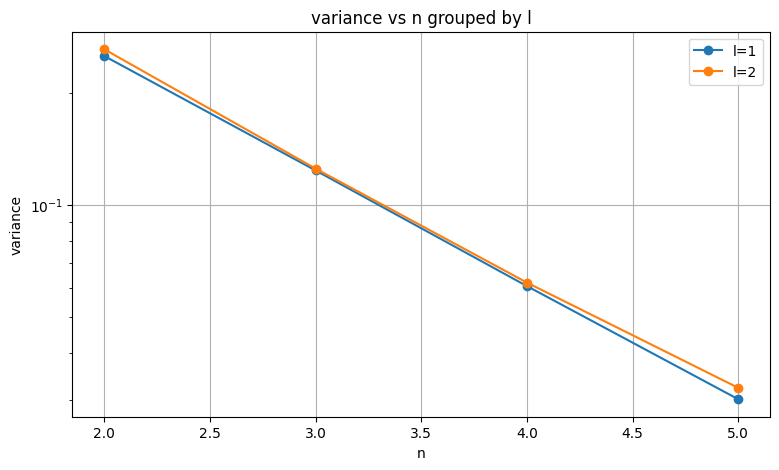

In [8]:
OVERALL_X = "n"
OVERALL_Y = "variance"
OVERALL_GROUP_BY = ["l"]  # A column, list of columns, or None

OVERALL_NS = None                # e.g. [2, 3, 4]
OVERALL_LS = None                # e.g. [1, 2, 4]
OVERALL_CIRCUITS = None          # e.g. ["multiscale_tree", "uni2"]
OVERALL_INITIAL_STATES = None    # e.g. ["positive_periodic_wave"]

overall_plot_data, ax = an.plot_gradient_run_table(
    gradient_run_stats,
    x=OVERALL_X,
    y=OVERALL_Y,
    ns=OVERALL_NS,
    ls=OVERALL_LS,
    circuits=OVERALL_CIRCUITS,
    initial_states=OVERALL_INITIAL_STATES,
    group_by=OVERALL_GROUP_BY,
    kind="line",              # "line" or "scatter"
    log_x=False,
    log_y=True,
)
overall_plot_data


## Configurable plots for individual parameters

`PARAMETERS` accepts ordinary indices (`0`, `3`), negative Python-style indices (`-1` is the last parameter), and `"mid"`. The `"mid"` selector is resolved independently for every run as the middle parameter of its middle repeated circuit layer; for even counts, the later of the two middle choices is used. Group by `parameter_selection` when comparing multiple selectors.


,full_label,n,l,circuit,initial_state,dt,mu,dx,diffusion_number,number_of_parameters,...,circuit_3_mean_gradient,circuit_3_mean_gradient_norm,circuit_3_variance,circuit_4_mean_gradient,circuit_4_mean_gradient_norm,circuit_4_variance,circuit_5_mean_gradient,circuit_5_mean_gradient_norm,circuit_5_variance,parameter_selection
0,tests_N2L1,2,1,default,sine,0.01,0.01,0.333333,0.0009,4,...,-0.054987,0.204496,0.057386,-0.039184,0.104113,0.013822,-0.001671,0.104129,0.015124,0
1,tests_N2L1,2,1,default,sine,0.01,0.01,0.333333,0.0009,4,...,0.055843,0.210555,0.059799,-0.001628,0.103309,0.015145,-0.009278,0.104362,0.015366,-1
2,tests_N2L1,2,1,default,sine,0.01,0.01,0.333333,0.0009,4,...,-0.054115,0.213763,0.061063,-0.002372,0.104357,0.015543,-0.001293,0.104573,0.015491,mid
3,tests_N2L2,2,2,default,sine,0.01,0.01,0.333333,0.0009,6,...,0.032258,0.215638,0.063583,0.003723,0.108160,0.016087,0.006332,0.105608,0.015406,0
4,tests_N2L2,2,2,default,sine,0.01,0.01,0.333333,0.0009,6,...,-0.003025,0.213789,0.063060,0.003708,0.106645,0.015823,-0.008757,0.104792,0.015457,-1
5,tests_N2L2,2,2,default,sine,0.01,0.01,0.333333,0.0009,6,...,0.006087,0.213541,0.062409,0.000550,0.105551,0.015747,0.007844,0.102924,0.015145,mid
6,tests_N3L1,3,1,default,sine,0.01,0.01,0.142857,0.0049,6,...,-0.005565,0.136621,0.029118,0.009817,0.046555,0.003321,0.004865,0.048220,0.003512,0
7,tests_N3L1,3,1,default,sine,0.01,0.01,0.142857,0.0049,6,...,0.001823,0.135107,0.028691,0.001311,0.049448,0.003715,0.008902,0.049863,0.003753,-1
8,tests_N3L1,3,1,default,sine,0.01,0.01,0.142857,0.0049,6,...,0.025980,0.147955,0.032993,-0.003574,0.049219,0.003735,-0.000732,0.046694,0.003364,mid
9,tests_N3L2,3,2,default,sine,0.01,0.01,0.142857,0.0049,9,...,-0.007198,0.143821,0.030825,0.006450,0.053671,0.004191,0.000759,0.052321,0.004073,0


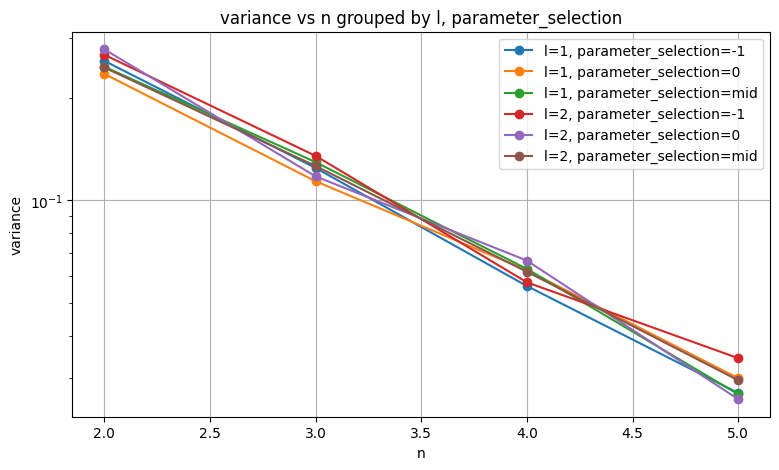

In [9]:
PARAMETER_X = "n"
PARAMETER_Y = "variance"
PARAMETERS = [0, -1, "mid"]
PARAMETER_GROUP_BY = ["l", "parameter_selection"]

PARAMETER_NS = None                # e.g. [2, 3, 4]
PARAMETER_LS = None                # e.g. [1, 2, 4]
PARAMETER_CIRCUITS = None          # e.g. ["multiscale_tree", "uni2"]
PARAMETER_INITIAL_STATES = None    # e.g. ["positive_periodic_wave"]

parameter_plot_data, ax = an.plot_gradient_parameter_table(
    gradient_parameter_stats,
    x=PARAMETER_X,
    y=PARAMETER_Y,
    parameters=PARAMETERS,
    ns=PARAMETER_NS,
    ls=PARAMETER_LS,
    circuits=PARAMETER_CIRCUITS,
    initial_states=PARAMETER_INITIAL_STATES,
    group_by=PARAMETER_GROUP_BY,
    kind="line",                # "line" or "scatter"
    log_x=False,
    log_y=True,
)
parameter_plot_data


## Exponential scaling fits over N

For every selected `(L, initial_state, circuit)` combination, the next cell fits variance and mean gradient norm to $y=A\,b^N$. The fit is performed as $\log y=\log A+N\log b$. If several selected runs produce the same N-point, their metric values are averaged before fitting.


,metric,l,initial_state,circuit,amplitude_A,base_b,log_base,r2_log,n_points
0,variance,1,sine,default,1.031552,0.492946,-0.707355,0.999983,4
1,variance,2,sine,default,1.033970,0.497731,-0.697695,0.999214,4
2,mean_gradient_norm,1,sine,default,1.520904,0.808766,-0.212245,0.980349,4
3,mean_gradient_norm,2,sine,default,1.851353,0.818386,-0.200421,0.993775,4


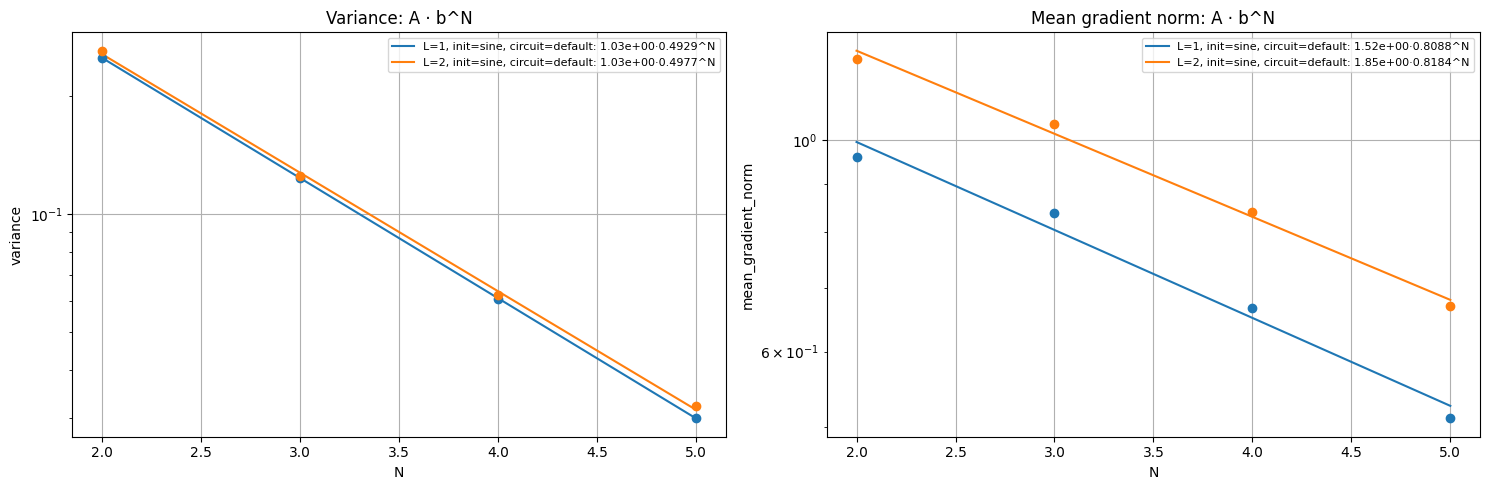

In [10]:
import pandas as pd

# Optional exact selection by full_label; leave as None to use the filters below.
FIT_RUNS = None  # e.g. ["grad_N2L1", "grad_N3L1", "grad_N4L1"]
FIT_NS = None  # e.g. [2, 3, 4, 5, 6]
FIT_LS = None  # e.g. [1, 2, 4]
FIT_INITIAL_STATES = None  # e.g. ["positive_periodic_wave"]
FIT_CIRCUITS = None  # e.g. ["multiscale_tree", "uni2"]

fit_data = an.filter_gradient_table(
    gradient_run_stats,
    ns=FIT_NS,
    ls=FIT_LS,
    circuits=FIT_CIRCUITS,
    initial_states=FIT_INITIAL_STATES,
)
if FIT_RUNS is not None:
    fit_run_labels = [FIT_RUNS] if isinstance(FIT_RUNS, str) else FIT_RUNS
    fit_data = fit_data[fit_data["full_label"].isin(fit_run_labels)].copy()
if fit_data.empty:
    raise ValueError("No gradient runs remain after applying the fit filters.")

group_columns = ["l", "initial_state", "circuit"]
metrics = [("variance", "Variance"), ("mean_gradient_norm", "Mean gradient norm")]
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)
fit_records = []
skipped_fits = []

for ax, (metric, title) in zip(axes, metrics):
    for group_values, group in fit_data.groupby(group_columns, dropna=False, sort=True):
        points = pd.DataFrame({
            "n": pd.to_numeric(group["n"], errors="coerce"),
            metric: pd.to_numeric(group[metric], errors="coerce"),
        }).dropna()
        points = points[np.isfinite(points[metric]) & (points[metric] > 0)]
        points = points.groupby("n", as_index=False)[metric].mean().sort_values("n")

        if points["n"].nunique() < 2:
            skipped_fits.append((metric, *group_values, "fewer than two positive N-points"))
            continue

        n_values = points["n"].to_numpy(dtype=float)
        y_values = points[metric].to_numpy(dtype=float)
        log_base, log_amplitude = np.polyfit(n_values, np.log(y_values), 1)
        amplitude = float(np.exp(log_amplitude))
        base = float(np.exp(log_base))
        fitted_log_values = log_amplitude + log_base * n_values
        log_residual = np.sum((np.log(y_values) - fitted_log_values) ** 2)
        log_total = np.sum((np.log(y_values) - np.mean(np.log(y_values))) ** 2)
        r2_log = float(1 - log_residual / log_total) if log_total > 0 else np.nan

        l_value, initial_state, circuit = group_values
        group_label = f"L={l_value}, init={initial_state}, circuit={circuit}"
        n_fit = np.linspace(n_values.min(), n_values.max(), 200)
        fit_line, = ax.plot(
            n_fit,
            amplitude * base**n_fit,
            label=f"{group_label}: {amplitude:.2e}·{base:.4f}^N",
        )
        ax.scatter(n_values, y_values, color=fit_line.get_color(), zorder=3)
        fit_records.append({
            "metric": metric,
            "l": l_value,
            "initial_state": initial_state,
            "circuit": circuit,
            "amplitude_A": amplitude,
            "base_b": base,
            "log_base": float(log_base),
            "r2_log": r2_log,
            "n_points": len(n_values),
        })

    ax.set_title(f"{title}: A · b^N")
    ax.set_xlabel("N")
    ax.set_ylabel(metric)
    ax.set_yscale("log")
    if ax.has_data():
        ax.legend(fontsize=8)

fig.tight_layout()
fit_results = pd.DataFrame(fit_records)
if skipped_fits:
    print("Skipped fits:")
    for skipped in skipped_fits:
        print("  ", skipped)
fit_results


## Raw gradients

The dictionaries below expose both the saved raw tensors and every reconstructed parameter-by-sweep matrix. For example, use `gradient_components[run_label]["circuit_1"][parameter_index]` or `gradient_components[run_label]["contribution_2"]`.


In [13]:
gradient_circuit_derivatives = {
    row["full_label"]: an.load_gradient_circuit_derivatives(row)
    for row in selected_gradient_runs
}
gradient_components = {
    row["full_label"]: an.load_gradient_components(row)
    for row in selected_gradient_runs
}
{run: {name: values.shape for name, values in components.items()}
 for run, components in gradient_components.items()}


{'tests_N2L1': {'current_dt': (4, 1250), 'fixed_diffusion': (4, 1250)},
 'tests_N2L2': {'current_dt': (6, 833), 'fixed_diffusion': (6, 833)},
 'tests_N2L4': {'current_dt': (10, 500), 'fixed_diffusion': (10, 500)},
 'tests_N3L1': {'current_dt': (6, 833), 'fixed_diffusion': (6, 833)},
 'tests_N3L2': {'current_dt': (9, 555), 'fixed_diffusion': (9, 555)},
 'tests_N3L4': {'current_dt': (15, 333), 'fixed_diffusion': (15, 333)},
 'tests_N4L1': {'current_dt': (8, 625), 'fixed_diffusion': (8, 625)}}

In [17]:
len(gradient_components["tests_N2L1"]["total"][0])

1250